# quiz 1 基礎

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

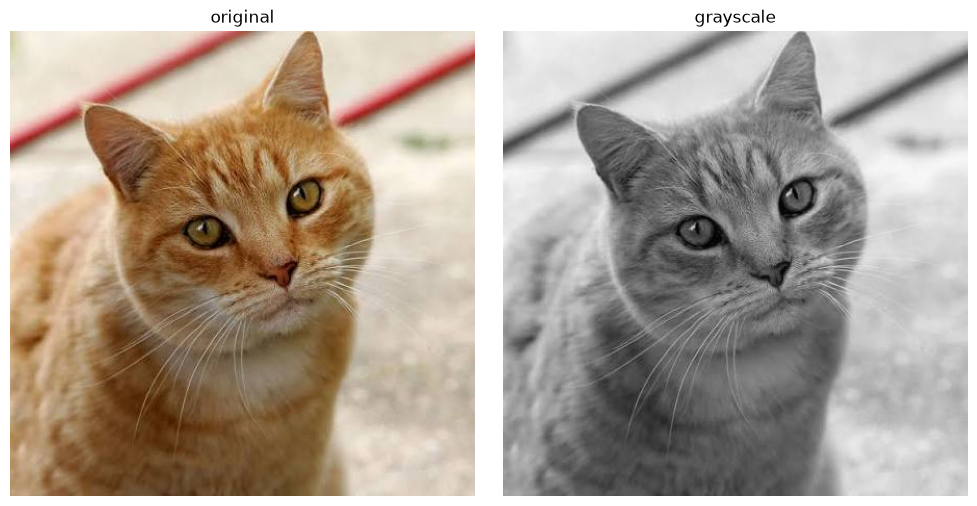

In [2]:
image = cv2.imread("./dataset/quiz1_1.jpg")

if image is None:
    raise FileNotFoundError("讀取圖片失敗")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("grayscale")
plt.axis("off")

plt.tight_layout()
plt.savefig("./result/quiz1_1.jpg")
plt.show()

# quiz 1 進階

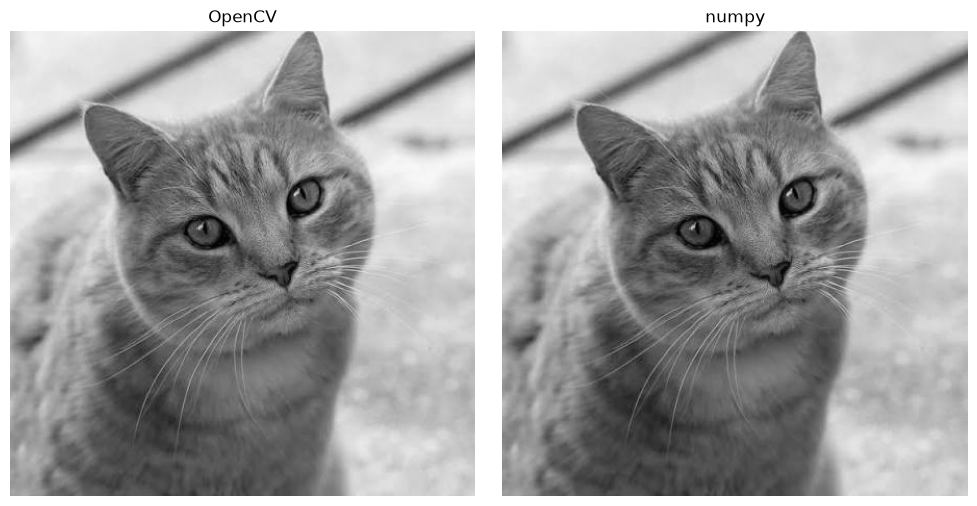

In [3]:
from other_code.quiz1 import grayscale_mean

image = cv2.imread("./dataset/quiz1_1.jpg")
if image is None:
    raise FileNotFoundError("讀取圖片失敗")

gray_cv2 = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_numpy = grayscale_mean(image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_cv2, cmap="gray", vmin=0, vmax=255)
plt.title("OpenCV")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_numpy, cmap="gray", vmin=0, vmax=255)
plt.title("numpy")
plt.axis("off")

plt.tight_layout()
plt.savefig("./result/quiz1_2.jpg")
plt.show()

執行N次 執行時間取平均

In [4]:
from time import perf_counter

In [5]:
N = 10
image = cv2.imread("./dataset/quiz1_1.jpg")
if image is None:
    raise FileNotFoundError("讀取圖片失敗")

# OpenCV
start = perf_counter()
for n in range(N):
    cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
opencv_avg = (perf_counter() - start) / N

# numpy
start = perf_counter()
for n in range(N):
    grayscale_mean(image)
numpy_avg = (perf_counter() - start) / N

print(f"重複次數：{N}")
print(f"OpenCV 平均耗時：{opencv_avg * 1000:.3f} ms")
print(f"自行實作(numpy)平均耗時：{numpy_avg * 1000:.3f} ms")
print(f"平均時間差(自行實作 − OpenCV)：{(numpy_avg - opencv_avg) * 1000:.3f} ms")

重複次數：10
OpenCV 平均耗時：0.174 ms
自行實作(numpy)平均耗時：289.436 ms
平均時間差(自行實作 − OpenCV)：289.262 ms


# quiz 2 基礎

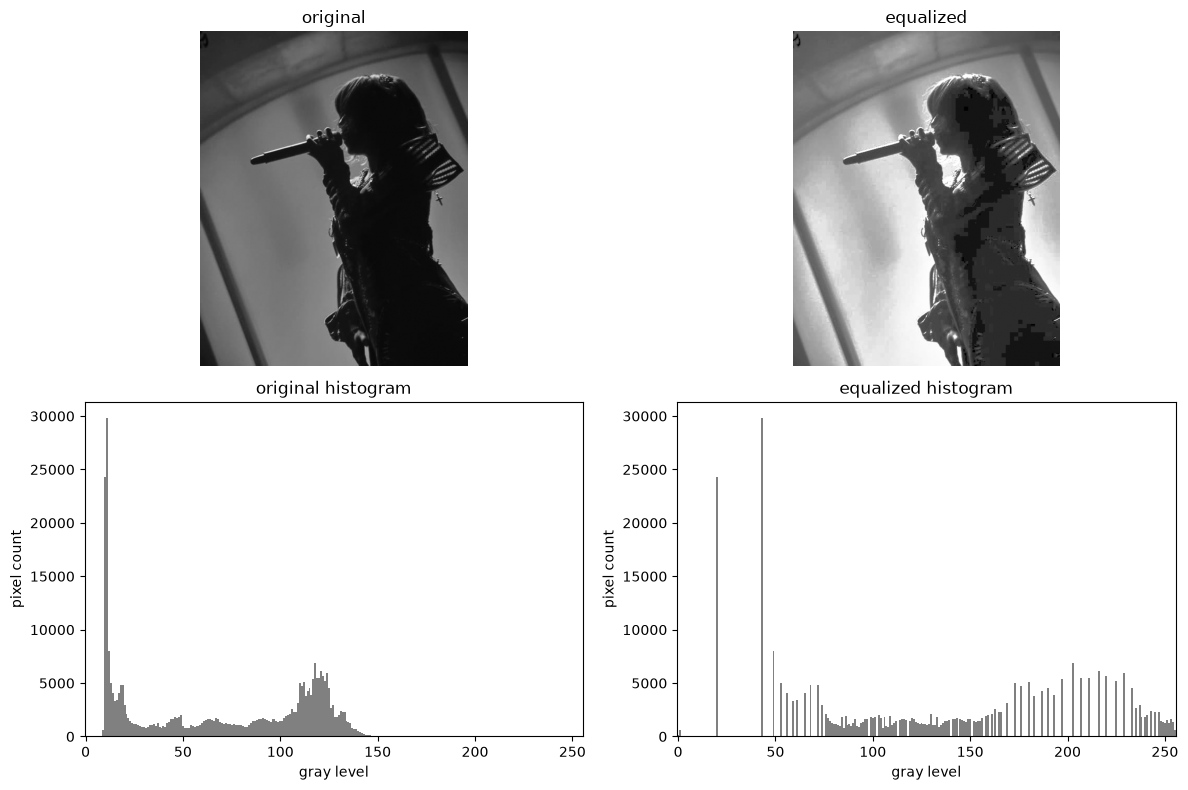

In [6]:
image = cv2.imread("./dataset/quiz2_1.jpg")
if image is None:
    raise FileNotFoundError("讀取圖片失敗")

gray_original = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_equalized = cv2.equalizeHist(gray_original)

hist_original = cv2.calcHist([gray_original], [0], None, [256], [0, 256])
hist_equalized = cv2.calcHist([gray_equalized], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray_original, cmap="gray", vmin=0, vmax=255)
plt.title("original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gray_equalized, cmap="gray", vmin=0, vmax=255)
plt.title("equalized")
plt.axis("off")

max_count = max(hist_original.max(), hist_equalized.max())

plt.subplot(2, 2, 3)
plt.bar(range(256), hist_original.ravel(), width=1, color="gray")
plt.title("original histogram")
plt.xlabel("gray level")
plt.ylabel("pixel count")
plt.xlim(-0.5, 255.5)
plt.ylim(0, max_count * 1.05)

plt.subplot(2, 2, 4)
plt.bar(range(256), hist_equalized.ravel(), width=1, color="gray")
plt.title("equalized histogram")
plt.xlabel("gray level")
plt.ylabel("pixel count")
plt.xlim(-0.5, 255.5)
plt.ylim(0, max_count * 1.05)

plt.tight_layout()
plt.savefig("./result/quiz2_1.jpg")
plt.show()

# quiz 2 進階

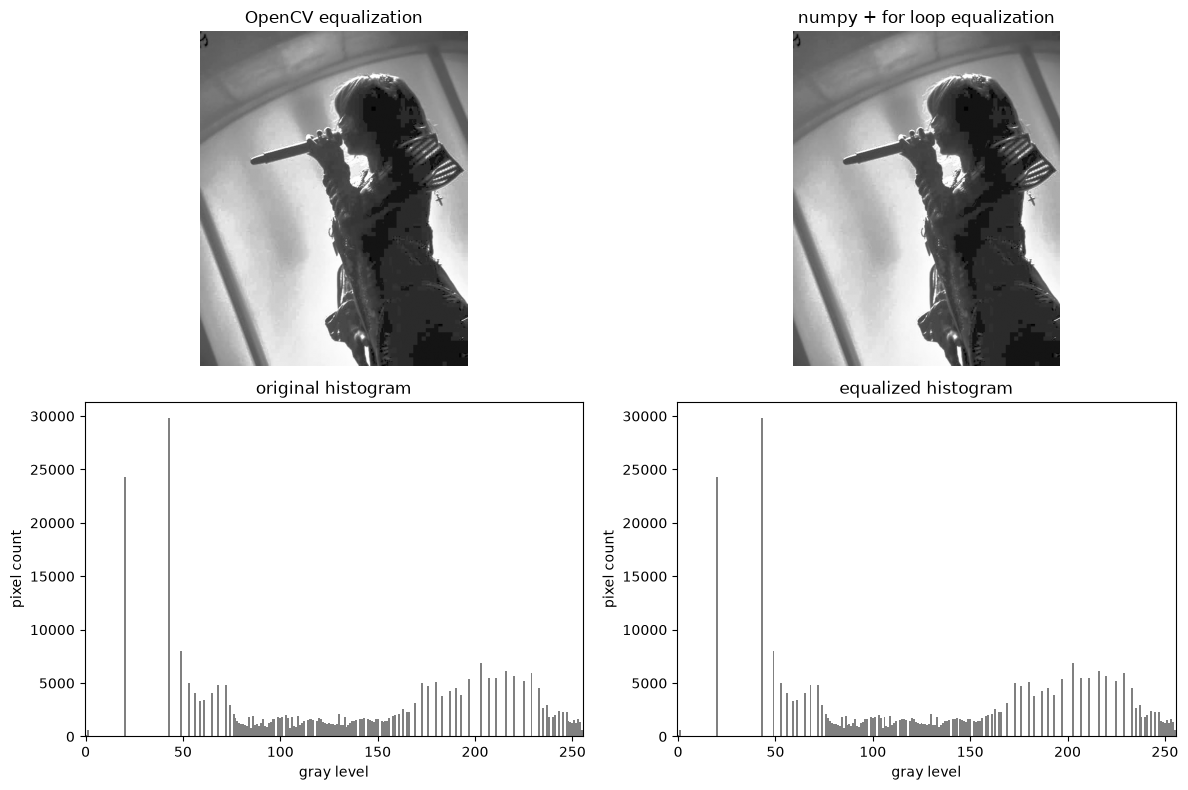

In [7]:
from other_code.quiz2 import equalized_numpy

image = cv2.imread("./dataset/quiz2_1.jpg")
if image is None:
    raise FileNotFoundError("讀取圖片失敗")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray_cv2 = cv2.equalizeHist(gray_image)
gray_numpy = equalized_numpy(gray_image)

hist_cv2 = cv2.calcHist([gray_cv2], [0], None, [256], [0, 256])
hist_numpy = cv2.calcHist([gray_numpy], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray_cv2, cmap="gray", vmin=0, vmax=255)
plt.title("OpenCV equalization")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gray_numpy, cmap="gray", vmin=0, vmax=255)
plt.title("numpy + for loop equalization")
plt.axis("off")

max_count = max(hist_cv2.max(), hist_numpy.max())

plt.subplot(2, 2, 3)
plt.bar(range(256), hist_cv2.ravel(), width=1, color="gray")
plt.title("original histogram")
plt.xlabel("gray level")
plt.ylabel("pixel count")
plt.xlim(-0.5, 255.5)
plt.ylim(0, max_count * 1.05)

plt.subplot(2, 2, 4)
plt.bar(range(256), hist_numpy.ravel(), width=1, color="gray")
plt.title("equalized histogram")
plt.xlabel("gray level")
plt.ylabel("pixel count")
plt.xlim(-0.5, 255.5)
plt.ylim(0, max_count * 1.05)

plt.tight_layout()
plt.savefig("./result/quiz2_2.jpg")
plt.show()

執行N次 執行時間取平均

In [8]:
from other_code.quiz2 import equalized_numpy

N = 10
image = cv2.imread("./dataset/quiz2_1.jpg")
if image is None:
    raise FileNotFoundError("讀取圖片失敗")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# OpenCV
start = perf_counter()
for n in range(N):
    cv2.equalizeHist(gray_image)
opencv_avg = (perf_counter() - start) / N

# numpy
start = perf_counter()
for n in range(N):
    equalized_numpy(gray_image)
numpy_avg = (perf_counter() - start) / N

print(f"重複次數：{N}")
print(f"OpenCV 平均耗時：{opencv_avg * 1000:.3f} ms")
print(f"自行實作(numpy)平均耗時：{numpy_avg * 1000:.3f} ms")
print(f"平均時間差(自行實作 − OpenCV)：{(numpy_avg - opencv_avg) * 1000:.3f} ms")

重複次數：10
OpenCV 平均耗時：0.556 ms
自行實作(numpy)平均耗時：232.996 ms
平均時間差(自行實作 − OpenCV)：232.440 ms


# quiz 3 基礎

原圖角落座標(左上、右上、右下、左下)
[[ 161.20493  465.82306]
 [ 876.40985  461.27844]
 [1005.8279  1261.1307 ]
 [  90.81967 1292.943  ]]


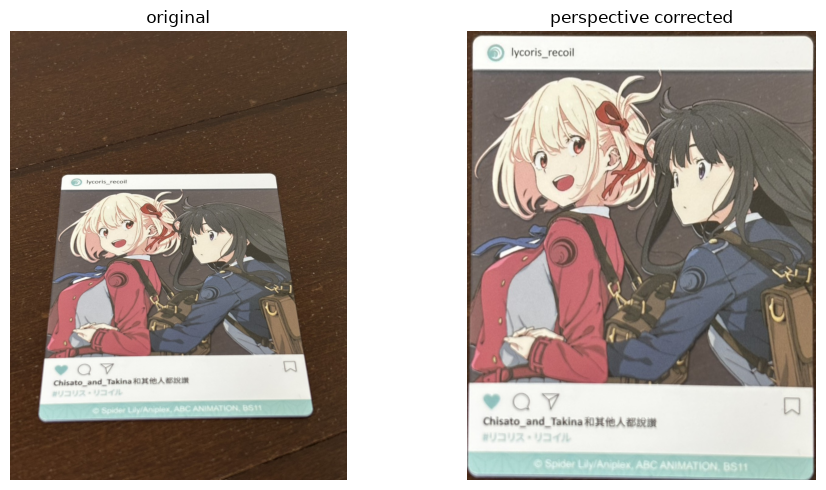

In [16]:
from other_code.quiz3 import select_corners,correct_perspective

filename = "quiz3_1"
image_path = f"./dataset/{filename}.jpg"
output_path = f"./result/{filename}.jpg"

image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError("讀取圖片失敗")

source_points = select_corners(image)

if source_points is None:
    print("已取消點選")
    
else:
    print("原圖角落座標(左上、右上、右下、左下)")
    print(source_points)
    
    corrected = correct_perspective(image, source_points)
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("original")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    plt.title("perspective corrected")
    plt.axis("off")
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

# quiz 3 進階

排序後的四個角
[[ 332.  424.]
 [ 798.  413.]
 [ 887. 1164.]
 [ 211. 1158.]]
輸出尺寸：寬676 * 高756


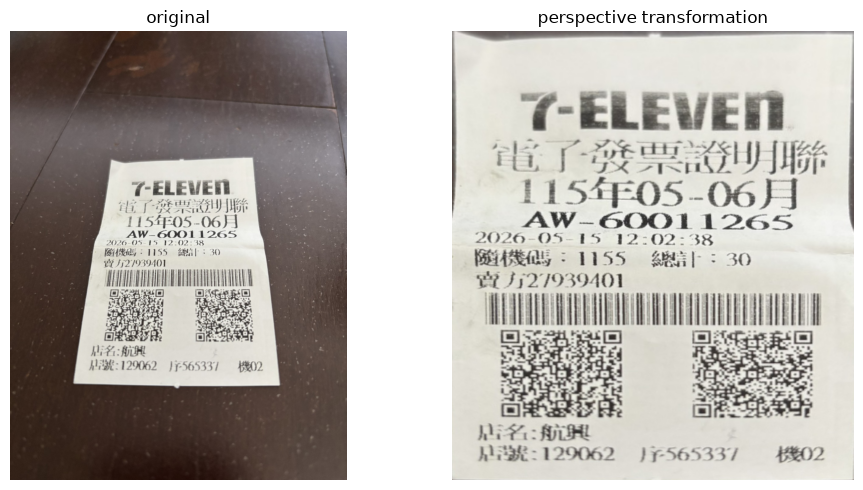

In [15]:
from other_code.quiz3 import find_corners, order_points, warp_image

filename = "quiz3_2"
image_path = f"./dataset/{filename}.jpg"
output_path = f"./result/{filename}.jpg"

image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError("讀取圖片失敗")

binary, approx = find_corners(image)

if approx is not None:
    ordered_points = order_points(approx)
    print("排序後的四個角")
    print(ordered_points)
    
    corrected = warp_image(image, ordered_points)
    height, width = corrected.shape[:2]
    print(f"輸出尺寸：寬{width} * 高{height}")
    
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    plt.title("perspective transformation")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    
else:
    print("無法校正")